In [8]:
import warnings
warnings.filterwarnings("ignore")

import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import *
from src.feature_engineering import *
from src.train import *
from src.evaluate import *

In [2]:
df = load_dataset("../dataset/hdfc_loan_dataset_full_enriched.csv")
df = basic_cleaning(df)

In [3]:
df = create_features(df)

In [4]:
missing_value_summary(df)

,Missing Values,Percentage
Business_Type,799,79.9
Co-signer_Relationship,234,23.4


In [5]:
features = [
    "Applicant_Income",
    "Coapplicant_Income",
    "Loan_Amount",
    "Credit_History",
    "CIBIL_Score",
    "Employment_Status",
    "Existing_EMIs",
    "Debt_to_Income_Ratio",
    "Education",
    "Property_Area",

    "Total_Income",
    "Loan_Income_Ratio",
    "EMI_Income_Ratio"

]

target = "Loan_Status"
X, y = select_features(
    df,
    features,
    target
)

In [9]:
le = LabelEncoder()
y = le.fit_transform(y)

In [10]:
num_features, cat_features = get_feature_types(X)

In [11]:
preprocessor = create_preprocessor(
    num_features,
    cat_features
)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (800, 13)
Testing Shape : (200, 13)


In [35]:
lr_pipeline = build_pipeline(
    preprocessor,
    LogisticRegression(random_state=42),
)

In [36]:
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Applicant_Income','Coapplicant_Income','Loan_Amount',...,'Total_Income', 'Loan_Income_Ratio','EMI_Income_Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``)

In [37]:
lr_pred = predict(
    lr_pipeline,
    X_test
)

In [39]:
lr_results = evaluate_classification(
    y_test,
    lr_pred,
)
lr_results

,Accuracy,Precision,Recall,F1 Score
0,0.81,0.806783,0.81,0.806969


In [29]:
dt_pipeline = build_pipeline(
    preprocessor,
    DecisionTreeClassifier(random_state=42)
)

In [30]:
dt_pipeline.fit(X_train, y_train)
dt_pred = predict(
    dt_pipeline,
    X_test
)

In [34]:
dt_results = evaluate_classification(
    y_test,
    dt_pred,
)
dt_results

,Accuracy,Precision,Recall,F1 Score
0,0.82,0.821358,0.82,0.820593


In [40]:
rf_pipeline = build_pipeline(
    preprocessor,
    RandomForestClassifier(random_state=42)
)

rf_pipeline.fit(X_train,y_train)
rf_pred = predict(
    rf_pipeline,
    X_test
)

rf_result = evaluate_classification(
    y_test,
    rf_pred
)
rf_result

,Accuracy,Precision,Recall,F1 Score
0,0.845,0.843231,0.845,0.843538


In [41]:
rf_params = {
    "classifier__n_estimators":[100,200],
    "classifier__max_depth":[5,10,15],
    "classifier__min_samples_split":[2,5],
    "classifier__min_samples_leaf":[1,2]
}

In [42]:
grid_rf = perform_grid_search(
    rf_pipeline,
    rf_params,
    X_train,
    y_train
)

In [43]:
best_rf = grid_rf.best_estimator_

In [44]:
grid_pred = predict(
    best_rf,
    X_test
)

In [45]:
results = evaluate_classification(
    y_test,
    grid_pred
)
results

,Accuracy,Precision,Recall,F1 Score
0,0.835,0.833606,0.835,0.834101


In [53]:
print_classification_report(
    y_test,
    grid_pred
)

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       131
           1       0.77      0.74      0.76        69

    accuracy                           0.83       200
   macro avg       0.82      0.81      0.82       200
weighted avg       0.83      0.83      0.83       200



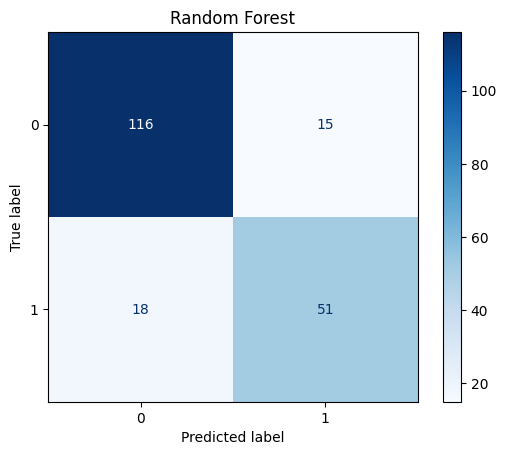

In [54]:
plot_confusion_matrix(
    y_test,
    grid_pred,
    "Random Forest"
)

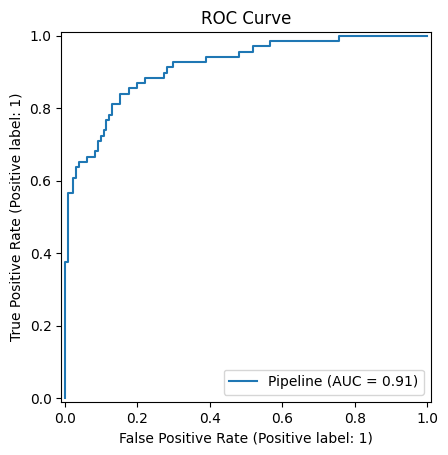

In [55]:
plot_roc_curve(
    best_rf,
    X_test,
    y_test
)

In [56]:
feature_names = best_rf.named_steps[
    "preprocessor"
].get_feature_names_out()

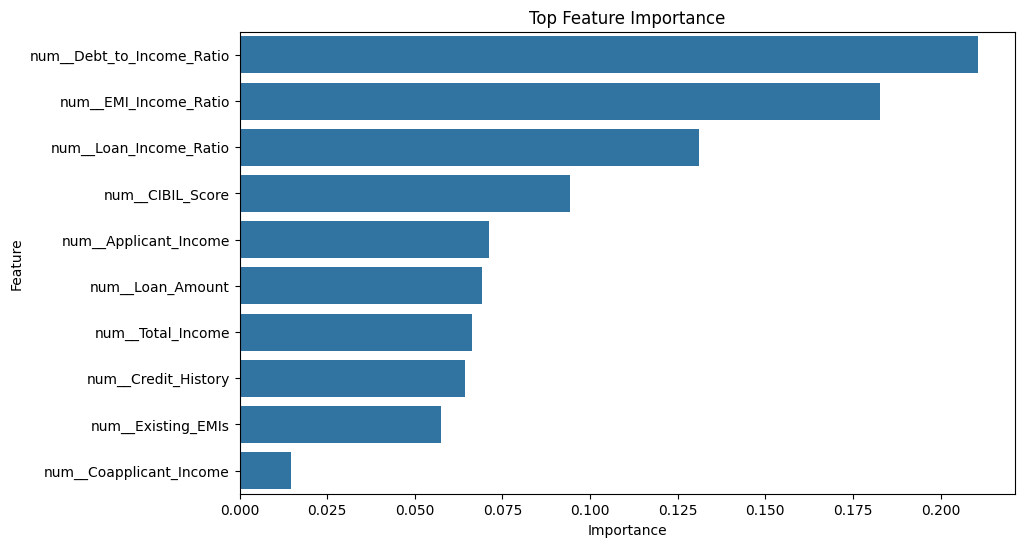

,Feature,Importance
6,num__Debt_to_Income_Ratio,0.210623
9,num__EMI_Income_Ratio,0.182839
8,num__Loan_Income_Ratio,0.131190
4,num__CIBIL_Score,0.094186
0,num__Applicant_Income,0.071187
2,num__Loan_Amount,0.069237
7,num__Total_Income,0.066406
3,num__Credit_History,0.064278
5,num__Existing_EMIs,0.057365
1,num__Coapplicant_Income,0.014597


In [57]:
plot_feature_importance(
    best_rf,
    feature_names
)

In [58]:
joblib.dump(
    best_rf,
    "../models/loan_approval_model.pkl"
)

['../models/loan_approval_model.pkl']